In [62]:
%load_ext autoreload
%autoreload 2

import os
import sys
import random
from pathlib import Path

import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


def find_root(current_path):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return current_path


PROJECT_ROOT = find_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets" / "large_20grid"
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "large_20grid"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

print(f"Project root found at: {PROJECT_ROOT}")
print(f"Loading source from: {SRC_DIR}")

from rl_methods.mdp import DiscreteMDP, Planner
from rl_methods import PolicySolver, EnvDataCollector
from rl_methods.fogas import (
    FOGASSolver,
    FOGASOracleSolver,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from rl_methods.dataset_collection import DatasetAnalyzer
from rl_methods.fqi.fqi_solver import FQISolver
from rl_methods.fqi.fqi_evaluator import FQIEvaluator
from rl_methods.data_collection import DiscreteDataBuffer
from rl_methods.data_collection import DatasetAnalyzer

# Now define the dataset path
DATASET_PATH = DATASETS_DIR / "large_10grid_coarse.csv"
DATASET_PATH1 = DATASETS_DIR / "20grid_coarse.csv"
print(f"Loading dataset from: {DATASET_PATH}")

seed = 44
np.random.seed(seed) # Add this
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root found at: /shared/home/mauro.diaz/work/FOGAS
Loading source from: /shared/home/mauro.diaz/work/FOGAS/src
Loading dataset from: /shared/home/mauro.diaz/work/FOGAS/data/datasets/large_20grid/large_10grid_coarse.csv
Using device: cuda


### Plotting and Scaling Helpers

In [63]:
def scale_grid(small_grid, factor=2):
    """
    Scales a grid by repeating each cell in rows and columns.
    Example: 10x10 with factor=2 becomes 20x20.
    """
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)

    large_grid[large_grid == "S"] = "."
    large_grid[large_grid == "G"] = "."

    large_grid[0, 0] = "S"
    large_grid[-1, -1] = "G"

    return large_grid


def _grid_major_step(size):
    if size <= 20:
        return 5
    if size <= 80:
        return 10
    return 20


def plot_fogas_grid(grid_data):
    size = grid_data.shape[0]

    mapping = {".": 0, "#": 1, "P": 2, "S": 3, "G": 4}
    labels = {0: "Empty", 1: "Wall", 2: "Pit", 3: "Start", 4: "Goal"}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ["#F5F5F5", "#2C2C2C", "#E63946", "#457B9D", "#2DC653"]
    cmap = mcolors.ListedColormap(colors)

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(numeric_grid, cmap=cmap, vmin=0, vmax=4, interpolation="nearest", origin="upper")

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    ax.set_title(f"FOGAS Environment - {size}x{size} Grid", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    patches = [
        mpatches.Patch(color=colors[i], label=f"{list(mapping.keys())[i]}  {labels[i]}")
        for i in range(len(colors))
    ]

    ax.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()


def plot_agent_paths_with_labels(grid_data, paths, labels=None, title_suffix="", alpha=0.75):
    size = grid_data.shape[0]

    mapping = {".": 0, "#": 1, "P": 2, "S": 3, "G": 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ["#F5F5F5", "#2C2C2C", "#E63946", "#457B9D", "#2DC653"]
    cmap = mcolors.ListedColormap(colors)

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(numeric_grid, cmap=cmap, vmin=0, vmax=4, interpolation="nearest", origin="upper")

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)

    line_styles = ["-", "--", ":", "-."]
    path_colors = ["magenta", "cyan", "yellow", "orange", "lime", "purple"]

    for i, path in enumerate(paths):
        if not path:
            continue

        label = labels[i] if labels and i < len(labels) else f"Path {i + 1}"
        rows, cols = zip(*path)
        color = path_colors[i % len(path_colors)]

        ax.plot(
            cols,
            rows,
            label=label,
            color=color,
            linestyle=line_styles[i % len(line_styles)],
            linewidth=2,
            marker="o",
            markersize=3,
            alpha=alpha,
        )

        ax.scatter(cols[0], rows[0], marker="s", s=60, color=color, zorder=5)
        ax.scatter(cols[-1], rows[-1], marker="*", s=120, color=color, zorder=5)

    ax.set_title(f"FOGAS Path Comparison: {size}x{size} {title_suffix}", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

def plot_occupancy_grid(planner, mdp_data, size, title_suffix="", mask_terminals=True):
    """
    Plot the optimal state occupancy from a clean Planner on a square grid.

    Works for 10x10, 20x20, 40x40, etc.
    """
    probs = planner.state_mu_star.detach().cpu().numpy().copy()

    terminal_states = set(mdp_data["pits"]) | {mdp_data["goal"]}

    if mask_terminals:
        for idx in terminal_states:
            probs[idx] = 0.0

    occupancy_grid = probs.reshape(size, size)
    positive_probs = probs[probs > 0]

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    norm = LogNorm(
        vmin=positive_probs.min() if len(positive_probs) else 1e-6,
        vmax=max(probs.max(), 1e-6),
    )

    im = ax.imshow(
        occupancy_grid,
        cmap="YlGnBu",
        norm=norm,
        interpolation="nearest",
        origin="upper",
    )

    # Cell boundaries, same style as plot_fogas_grid
    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Adaptive major tick labels
    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    # Mark start, goal, pits, walls
    start = mdp_data["start"]
    goal = mdp_data["goal"]

    start_r, start_c = divmod(start, size)
    goal_r, goal_c = divmod(goal, size)

    ax.scatter(start_c, start_r, marker="s", s=90, color="#457B9D", edgecolor="black", label="Start", zorder=5)
    ax.scatter(goal_c, goal_r, marker="*", s=180, color="#2DC653", edgecolor="black", label="Goal", zorder=5)

    for pit in mdp_data["pits"]:
        r, c = divmod(pit, size)
        ax.scatter(c, r, marker="x", s=80, color="#E63946", linewidths=2, label="Pit" if pit == next(iter(mdp_data["pits"])) else None, zorder=5)

    for wall in mdp_data["walls"]:
        r, c = divmod(wall, size)
        ax.add_patch(
            plt.Rectangle(
                (c - 0.5, r - 0.5),
                1,
                1,
                facecolor="#2C2C2C",
                edgecolor="none",
                alpha=0.85,
                zorder=4,
            )
        )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Log Occupancy Probability", fontsize=10)

    masked_text = "excluding terminal states" if mask_terminals else "including terminal states"
    ax.set_title(
        f"Optimal State Occupancy - {size}x{size} Grid {title_suffix}\n{masked_text}",
        fontsize=14,
        pad=12,
    )
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    plt.tight_layout()
    plt.show()

### 10x10 and 20x20 grid used

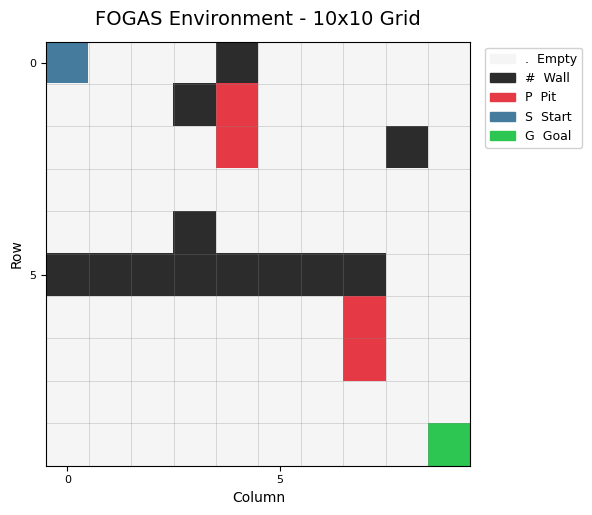

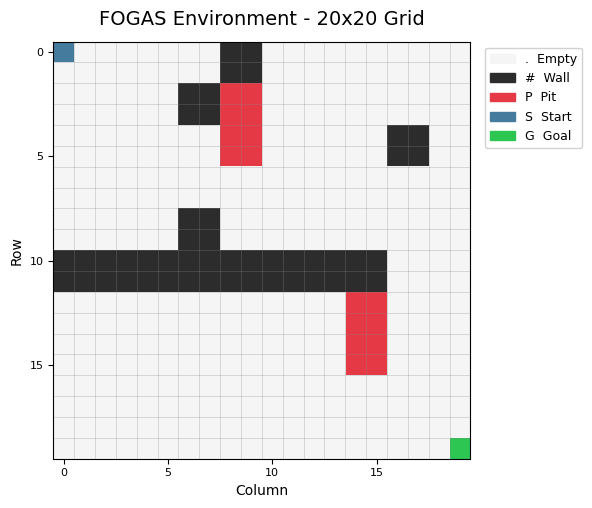

In [64]:
grid_layout = [
    "S...#.....",
    "...#P.....",
    "....P...#.",
    "..........",
    "...#......",
    "########..",
    ".......P..",
    ".......P..",
    "..........",
    ".........G"
]

grid_10 = np.array([list(row) for row in grid_layout])
grid_20 = scale_grid(grid_10, factor=2)

plot_fogas_grid(grid_10)
plot_fogas_grid(grid_20)

### MDP and Features Helpers

In [65]:
def generate_mdp_regular_grid(grid_data, gamma=0.99):
    """
    Builds the grid-world MDP data from a character grid.

    What it creates:
    - walls, pits, start, goal from the grid
    - deterministic transition matrix P with 4 actions:
        0 = up, 1 = down, 2 = left, 3 = right
    - reward function:
        goal = +10
        pit = -10
        every other state = -0.01
    - normalized RBF centers in [0, 1] x [0, 1]
    """
    size = grid_data.shape[0]
    N = size * size
    A = 4

    walls = set(np.where(grid_data.flatten() == "#")[0])
    pits = set(np.where(grid_data.flatten() == "P")[0])
    goal = np.where(grid_data.flatten() == "G")[0][0]
    start_node = np.where(grid_data.flatten() == "S")[0][0]

    # Regular Grid Center Generation
    # Target 50% of the total states N.
    target_num_centers = int(N * 0.5)

    # Since centers are laid out as a square meshgrid, use sqrt(target).
    centers_per_side = int(np.sqrt(target_num_centers))

    # Centers live in normalized coordinate space [0, 1].
    ticks = np.linspace(0.0, 1.0, centers_per_side)
    c_x, c_y = np.meshgrid(ticks, ticks)
    centers = torch.tensor(
        np.column_stack([c_x.ravel(), c_y.ravel()]),
        dtype=torch.float64,
    )

    def reward_fn(x, a):
        x_int = int(x)
        if x_int == goal:
            return 10.0
        if x_int in pits:
            return -10.0
        return -0.01

    P = torch.zeros((N * A, N), dtype=torch.float64)

    for x in range(N):
        for a in range(A):
            if x in pits or x == goal:
                P[x * A + a, x] = 1.0
                continue

            r, c = divmod(x, size)

            if a == 0:
                r_n, c_n = max(0, r - 1), c
            elif a == 1:
                r_n, c_n = min(size - 1, r + 1), c
            elif a == 2:
                r_n, c_n = r, max(0, c - 1)
            elif a == 3:
                r_n, c_n = r, min(size - 1, c + 1)

            next_s = r_n * size + c_n

            if next_s in walls:
                next_s = x

            P[x * A + a, next_s] = 1.0

    return {
        "centers": centers,
        "walls": walls,
        "pits": pits,
        "goal": goal,
        "start": start_node,
        "reward_fn": reward_fn,
        "P": P,
        "N": N,
        "A": A,
        "gamma": gamma,
    }


def build_clean_mdp_from_grid_data(mdp_data):
    """
    Converts the mdp_data dictionary into fogas-compatible objects.

    Returns:
    - mdp: clean DiscreteMDP
    - planner: clean Planner with optimal policy/value/occupancy computed
    """
    terminal_states = list(mdp_data["pits"]) + [mdp_data["goal"]]

    mdp = DiscreteMDP(
        states=torch.arange(mdp_data["N"]),
        actions=torch.arange(mdp_data["A"]),
        reward_fn=mdp_data["reward_fn"],
        gamma=mdp_data["gamma"],
        x0=mdp_data["start"],
        P=mdp_data["P"],
        terminal_states=terminal_states,
    )

    planner = Planner(mdp)

    return mdp, planner


def get_phi_func(centers, sigma, size, pits, goal, A):
    """
    Returns state-action feature function for FOGAS:
    phi(x, a) = one_hot(a) kron phi_state(x)
    """
    def phi_state(x):
        r, c = divmod(int(x), size)

        coords = torch.tensor(
            [r / (size - 1), c / (size - 1)],
            dtype=torch.float64,
        )

        dist_sq = torch.sum((coords - centers) ** 2, dim=1)
        rbf = torch.exp(-dist_sq / (2 * sigma ** 2))

        is_pit = 1.0 if int(x) in pits else 0.0
        is_goal = 1.0 if int(x) == goal else 0.0
        indicators = torch.tensor([is_pit, is_goal], dtype=torch.float64)

        return torch.cat([rbf, torch.ones(1, dtype=torch.float64), indicators])

    def phi(x, a):
        state_feat = phi_state(x)
        d_state = state_feat.shape[0]

        out = torch.zeros(A * d_state, dtype=torch.float64)
        start = int(a) * d_state
        out[start:start + d_state] = state_feat

        return out

    return phi


def calculate_local_sigma(centers, k=2):
    """
    Computes an RBF sigma from average k-nearest-neighbor distance.

    This makes sigma adapt to the density of the regular center grid.
    """
    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)
    return torch.mean(topk_dists[:, 1])


def _grid_major_step(size):
    if size <= 20:
        return 5
    if size <= 80:
        return 10
    return 20


def plot_grid_with_centers(grid_data, centers):
    """
    Plots the grid and overlays the RBF feature centers.

    Works for 10x10, 20x20, 40x40, 100x100, etc.
    Centers are stored normalized in [0, 1], then scaled back to grid coordinates.
    """
    size = grid_data.shape[0]

    mapping = {".": 0, "#": 1, "P": 2, "S": 3, "G": 4}
    labels = {0: "Empty", 1: "Wall", 2: "Pit", 3: "Start", 4: "Goal"}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ["#F5F5F5", "#2C2C2C", "#E63946", "#457B9D", "#2DC653"]
    cmap = mcolors.ListedColormap(colors)

    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=4,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)

    grid_linewidth = 0.4 if size <= 80 else 0.25
    grid_alpha = 0.5 if size <= 80 else 0.35
    ax.grid(which="minor", color="#888888", linewidth=grid_linewidth, alpha=grid_alpha)
    ax.tick_params(which="minor", bottom=False, left=False)

    major_step = _grid_major_step(size)
    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    centers_scaled = centers.detach().cpu().numpy() * (size - 1)

    marker_size = max(15, min(80, 250 / np.sqrt(size)))
    ax.scatter(
        centers_scaled[:, 1],
        centers_scaled[:, 0],
        c="blue",
        marker="x",
        s=marker_size,
        label="RBF Feature Centers",
        alpha=0.65,
        linewidths=1.2,
    )

    patches = [
        mpatches.Patch(color=colors[i], label=f"{list(mapping.keys())[i]}  {labels[i]}")
        for i in range(len(colors))
    ]

    grid_legend = ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.0,
        fontsize=9,
        framealpha=0.9,
        title="Grid",
    )
    ax.add_artist(grid_legend)

    ax.legend(
        bbox_to_anchor=(1.02, 0.58),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    ax.set_title(f"FOGAS Feature Allocation - {size}x{size}", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    plt.tight_layout()
    plt.show()

def compute_optimal_path(planner, mdp_data, size, max_steps=1000):
    """
    Computes the optimal path from start to goal by following planner.pi_star.

    It starts from mdp_data["start"], chooses the best action from the optimal
    policy at each state, then uses the transition matrix P to move to the next
    state.

    Stops when:
    - the goal is reached
    - a pit is reached
    - the policy gets stuck
    - max_steps is reached
    """
    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = mdp_data["pits"]

    path = []

    for _ in range(max_steps):
        r, c = divmod(current_state, size)
        path.append((r, c))

        if current_state == goal_state or current_state in pits:
            break

        best_a = torch.argmax(planner.pi_star[current_state]).item()
        next_state = torch.argmax(planner.P[current_state * planner.A + best_a]).item()

        if next_state == current_state:
            break

        current_state = next_state

    return path

def sample_policy_path(mdp, mdp_data, size, pi, max_steps=1000, rng=None):
    """
    Sample one trajectory from a policy on a clean DiscreteMDP.

    Args:
        mdp: clean DiscreteMDP
        mdp_data: dict with start, goal, pits
        size: grid side length
        pi: policy tensor with shape (N, A)
    """
    if rng is None:
        rng = np.random.default_rng()

    pi = pi.detach().cpu() if isinstance(pi, torch.Tensor) else torch.as_tensor(pi)

    current_state = int(mdp_data["start"])
    goal_state = int(mdp_data["goal"])
    pits = set(mdp_data["pits"])

    path = []
    states = []
    actions = []

    for _ in range(max_steps):
        r, c = divmod(current_state, size)
        path.append((r, c))
        states.append(current_state)

        if current_state == goal_state or current_state in pits:
            break

        action_probs = pi[current_state].numpy()
        action_probs = action_probs / action_probs.sum()

        action = int(rng.choice(mdp.A, p=action_probs))
        actions.append(action)

        transition_probs = mdp.P[current_state * mdp.A + action].detach().cpu().numpy()
        next_state = int(rng.choice(mdp.N, p=transition_probs))

        if next_state == current_state:
            break

        current_state = next_state

    return path, states, actions


def sample_multiple_policy_paths(
    mdp,
    mdp_data,
    size,
    pi,
    n_paths=20,
    max_steps=1000,
    seed=None,
):
    rng = np.random.default_rng(seed)

    paths = []
    states_list = []
    actions_list = []

    for _ in range(n_paths):
        path, states, actions = sample_policy_path(
            mdp=mdp,
            mdp_data=mdp_data,
            size=size,
            pi=pi,
            max_steps=max_steps,
            rng=rng,
        )
        paths.append(path)
        states_list.append(states)
        actions_list.append(actions)

    return paths, states_list, actions_list


def unique_paths(paths):
    seen = set()
    out = []

    for path in paths:
        key = tuple(path)
        if key not in seen:
            seen.add(key)
            out.append(path)

    return out


def sample_unique_policy_paths(
    mdp,
    mdp_data,
    size,
    pi,
    n_samples=200,
    max_unique=10,
    max_steps=1000,
    seed=None,
):
    paths, _, _ = sample_multiple_policy_paths(
        mdp=mdp,
        mdp_data=mdp_data,
        size=size,
        pi=pi,
        n_paths=n_samples,
        max_steps=max_steps,
        seed=seed,
    )

    return unique_paths(paths)[:max_unique]

# Strategy 1 - Solve coarse grid

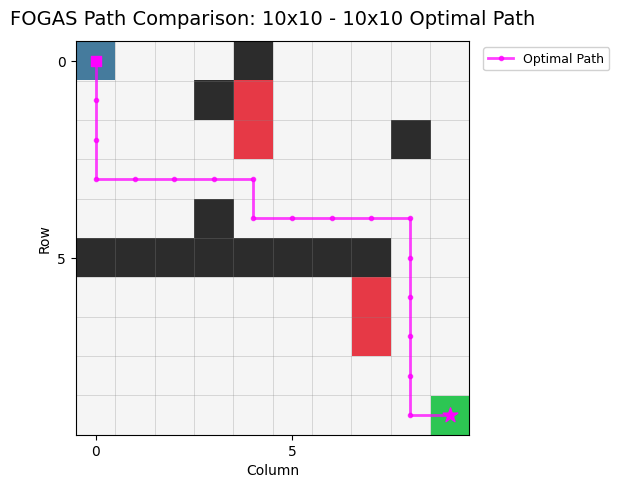

In [66]:
size_10 = grid_10.shape[0]

mdp_data_10 = generate_mdp_regular_grid(grid_10)

centers_10 = mdp_data_10["centers"]
sigma_10 = calculate_local_sigma(centers_10, k=2)

phi_10 = get_phi_func(
    centers_10,
    sigma_10,
    size_10,
    mdp_data_10["pits"],
    mdp_data_10["goal"],
    A=mdp_data_10["A"],
)

mdp_10, planner_10 = build_clean_mdp_from_grid_data(mdp_data_10)
optimal_path_10 = compute_optimal_path(planner_10, mdp_data_10, size=size_10)

plot_agent_paths_with_labels(
    grid_10,
    [optimal_path_10],
    labels=["Optimal Path"],
    title_suffix="- 10x10 Optimal Path",
)


### Data collection with occupancy measure

In [67]:
reset_options = {
    "x0": 0.1,
    "occupancy": 0.9,
}

collector_10 = DiscreteDataBuffer(
    mdp=mdp_10,
    restricted_states=mdp_data_10["walls"],
    reset_probs=reset_options,
    occupancy=planner_10.state_mu_star,   # clean Planner owns this now
    max_steps=200,
    seed=seed,
)

epsilon_policy_10 = (planner_10.pi_star, 0.3)  # 30% random, 70% pi_star

df_10 = collector_10.collect(
    policies=[epsilon_policy_10, "random"],
    proportions=[0.8, 0.2],
    n_steps=10_000,
    episode_based=True,
    extra_terminal_steps=50,
    save_path=str(DATASET_PATH),
    verbose=True,
)

Collected 10000 transitions over 143 episodes.
Policy distribution:
policy_id
0    0.7594
1    0.2406
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
occupancy    0.8024
x0           0.1976
Name: proportion, dtype: float64
Saved FOGAS dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets/large_20grid/large_10grid_coarse.csv


STATE COVERAGE
Total states:              100
Walls:                     12
Terminal states:           5
Visited states:            62
Unvisited non-wall states: 26
State coverage:            70.45%


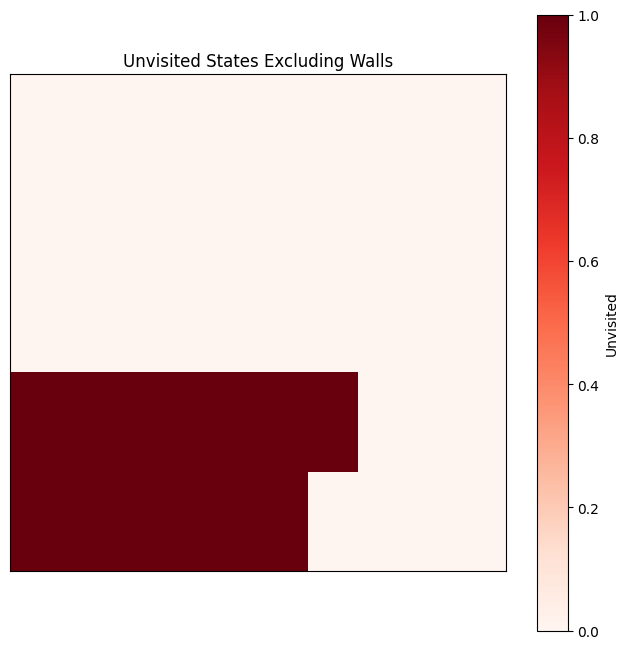

FEATURE COVERAGE
Coverage ratio: 2.082991
Dataset size:   10000
Feature dim:    208
Beta:           1e-06


In [68]:
# -----------------------------
# Dataset coverage diagnostics
# -----------------------------

df_current = df_10
mdp_current = mdp_10
planner_current = planner_10
mdp_data_current = mdp_data_10
phi_current = phi_10
dataset_path_current = DATASET_PATH
size_current = size_10

# Visited / missing states
visited_states = set(df_current["state"].unique())
wall_states = set(mdp_data_current["walls"])
terminal_states = set(mdp_data_current["pits"]) | {mdp_data_current["goal"]}
all_states = set(range(mdp_current.N))

non_visited_non_walls = all_states - visited_states - wall_states

print("=" * 50)
print("STATE COVERAGE")
print("=" * 50)
print(f"Total states:              {mdp_current.N}")
print(f"Walls:                     {len(wall_states)}")
print(f"Terminal states:           {len(terminal_states)}")
print(f"Visited states:            {len(visited_states)}")
print(f"Unvisited non-wall states: {len(non_visited_non_walls)}")
print(f"State coverage:            {len(visited_states) / (mdp_current.N - len(wall_states)):.2%}")

# Plot unvisited non-wall states
coverage_map = np.zeros((size_current, size_current), dtype=float)

for s in non_visited_non_walls:
    r, c = divmod(s, size_current)
    coverage_map[r, c] = 1.0

plt.figure(figsize=(8, 8))
plt.imshow(coverage_map, cmap="Reds", interpolation="nearest")
plt.title("Unvisited States Excluding Walls")
plt.colorbar(label="Unvisited")
plt.xticks([])
plt.yticks([])
plt.show()

# -----------------------------
# Feature coverage diagnostics
# -----------------------------

# Clean DatasetAnalyzer expects an explicit feature tensor:
# shape = (N, A, d)
Phi_current = torch.stack(
    [
        torch.stack(
            [phi_current(x, a) for a in range(mdp_current.A)],
            dim=0,
        )
        for x in range(mdp_current.N)
    ],
    dim=0,
)

analyzer = DatasetAnalyzer(df_current)

coverage = analyzer.feature_coverage(
    phi=Phi_current,
    optimal_occupancy=planner_current.mu_star,
    beta=1e-6,
    return_details=True,
)

print("=" * 50)
print("FEATURE COVERAGE")
print("=" * 50)
print(f"Coverage ratio: {coverage['coverage_ratio']:.6f}")
print(f"Dataset size:   {coverage['n']}")
print(f"Feature dim:    {Phi_current.shape[-1]}")
print(f"Beta:           {coverage['beta']}")

In [81]:
solver_10 = FOGASSolver(
    mdp=mdp_10,
    phi=phi_10,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-7,
    seed=seed,
)

evaluator_10 = FOGASEvaluator(
    solver=solver_10,
    planner=planner_10,
)

solver_10.run(
    alpha=0.0001 / 2,
    eta=0.00002,
    rho=0.5,
    T=15_000,
    tqdm_print=True,
)

[FOGASSolver] omega estimated via regression (beta_omega=1.00e-07, n=10000)


FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [00:13<00:00, 1118.00it/s]


tensor([[1.6698e-01, 4.0043e-01, 1.6339e-01, 2.6920e-01],
        [1.1119e-01, 2.9864e-01, 4.6783e-02, 5.4339e-01],
        [1.8200e-01, 2.9886e-01, 1.8843e-02, 5.0030e-01],
        [2.8969e-01, 4.1834e-01, 1.4756e-02, 2.7721e-01],
        [1.4931e-01, 5.0541e-01, 1.2265e-02, 3.3301e-01],
        [4.6904e-02, 3.4050e-01, 6.3668e-03, 6.0622e-01],
        [4.2481e-02, 2.2380e-01, 4.8917e-03, 7.2883e-01],
        [1.1535e-01, 2.6825e-01, 1.3813e-02, 6.0259e-01],
        [2.2033e-01, 3.4885e-01, 6.3440e-02, 3.6738e-01],
        [2.2395e-01, 3.5032e-01, 1.8043e-01, 2.4530e-01],
        [1.7358e-02, 7.9147e-01, 8.3009e-02, 1.0816e-01],
        [1.3655e-02, 6.8691e-01, 3.3259e-02, 2.6618e-01],
        [4.8507e-02, 6.3609e-01, 1.8297e-02, 2.9710e-01],
        [1.2879e-01, 7.2842e-01, 1.0918e-02, 1.3187e-01],
        [5.3488e-04, 9.9899e-01, 2.5099e-04, 2.2901e-04],
        [2.2128e-02, 7.7586e-01, 1.6032e-03, 2.0041e-01],
        [2.6533e-02, 6.1567e-01, 1.4089e-03, 3.5638e-01],
        [6.890

In [83]:
terminal_states_10 = list(mdp_data_10["pits"]) + [mdp_data_10["goal"]]

num_trajectories = 100
max_steps = 200

def discounted_return(traj, gamma):
    return sum((gamma ** step["step"]) * step["reward"] for step in traj)

returns_10 = []
successes_10 = []

for i in range(num_trajectories):
    traj = evaluator_10.simulate_trajectory(
        policy_mode="solver",
        max_steps=max_steps,
        seed=seed + i,
        goal_state=mdp_data_10["goal"],
        terminal_states=terminal_states_10,
    )

    returns_10.append(discounted_return(traj, mdp_10.gamma))
    successes_10.append(
        bool(traj) and traj[-1]["next_state"] == mdp_data_10["goal"]
    )

returns_10 = np.array(returns_10, dtype=float)
successes_10 = np.array(successes_10, dtype=bool)

# Optional optimal comparison
optimal_returns_10 = []
optimal_successes_10 = []

for i in range(num_trajectories):
    traj_opt = evaluator_10.simulate_trajectory(
        pi=planner_10.pi_star,
        max_steps=max_steps,
        seed=seed + i,
        goal_state=mdp_data_10["goal"],
        terminal_states=terminal_states_10,
    )

    optimal_returns_10.append(discounted_return(traj_opt, mdp_10.gamma))
    optimal_successes_10.append(
        bool(traj_opt) and traj_opt[-1]["next_state"] == mdp_data_10["goal"]
    )

optimal_returns_10 = np.array(optimal_returns_10, dtype=float)
optimal_successes_10 = np.array(optimal_successes_10, dtype=bool)

print("=" * 50)
print("FOGAS SIMULATION METRICS")
print("=" * 50)
print(f"Average return:       {returns_10.mean():.4f}")
print(f"Return std:           {returns_10.std(ddof=1):.4f}")
print(f"Optimal avg return:   {optimal_returns_10.mean():.4f}")
print(f"Optimal return std:   {optimal_returns_10.std(ddof=1):.4f}")
print(f"Return gap:           {optimal_returns_10.mean() - returns_10.mean():.4f}")
print()
print(f"Success rate:         {successes_10.mean():.2%}")
print(f"Optimal success:      {optimal_successes_10.mean():.2%}")
print(f"Success gap:          {optimal_successes_10.mean() - successes_10.mean():.2%}")

FOGAS SIMULATION METRICS
Average return:       -0.2917
Return std:           0.2185
Optimal avg return:   -0.1655
Optimal return std:   0.0000
Return gap:           0.1263

Success rate:         82.00%
Optimal success:      100.00%
Success gap:          18.00%


# Strategy 2- data collection in fine grid

Problem in collection: too many optimal paths!

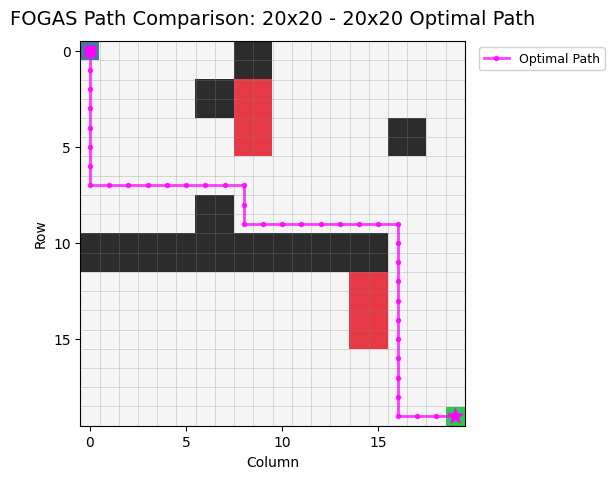

20x20:
  N=400, A=4
  feature_dim=208
Aligned with 10x10: True


In [71]:
# -----------------------------
# 20x20 setup using existing 10x10 feature space
# -----------------------------

grid_20 = scale_grid(grid_10, factor=2)
size_20 = grid_20.shape[0]

mdp_data_20 = generate_mdp_regular_grid(grid_20)

# Reuse the 10x10 feature centers/sigma so phi_10 and phi_20 are aligned.
fixed_centers = centers_10
fixed_sigma = sigma_10

phi_20 = get_phi_func(
    fixed_centers,
    fixed_sigma,
    size_20,
    mdp_data_20["pits"],
    mdp_data_20["goal"],
    A=mdp_data_20["A"],
)

mdp_20, planner_20 = build_clean_mdp_from_grid_data(mdp_data_20)

optimal_path_20 = compute_optimal_path(
    planner_20,
    mdp_data_20,
    size=size_20,
)

plot_agent_paths_with_labels(
    grid_20,
    [optimal_path_20],
    labels=["Optimal Path"],
    title_suffix="- 20x20 Optimal Path",
)

print("20x20:")
print(f"  N={mdp_20.N}, A={mdp_20.A}")
print(f"  feature_dim={phi_20(0, 0).numel()}")
print("Aligned with 10x10:", phi_20(0, 0).numel() == phi_10(0, 0).numel())

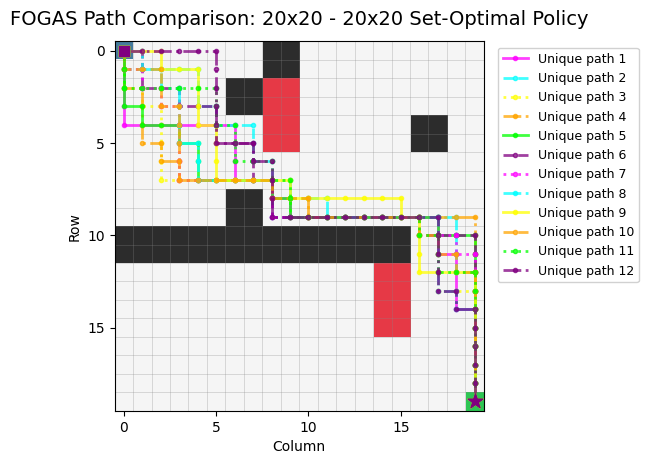

In [72]:
pi_set_20 = planner_20.policy_from_optimal_q(
    mode="set",
    tie_eps=1e-10,
)

paths_20, states_list_20, actions_list_20 = sample_multiple_policy_paths(
    mdp=mdp_20,
    mdp_data=mdp_data_20,
    size=size_20,
    pi=pi_set_20,
    n_paths=30,
    max_steps=500,
    seed=seed,
)

paths_unique_20 = sample_unique_policy_paths(
    mdp=mdp_20,
    mdp_data=mdp_data_20,
    size=size_20,
    pi=pi_set_20,
    n_samples=300,
    max_unique=12,
    max_steps=500,
    seed=seed,
)

labels_20 = [f"Unique path {i + 1}" for i in range(len(paths_unique_20))]

plot_agent_paths_with_labels(
    grid_data=grid_20,
    paths=paths_unique_20,
    labels=labels_20,
    title_suffix="- 20x20 Set-Optimal Policy",
)

### Coarse conversion

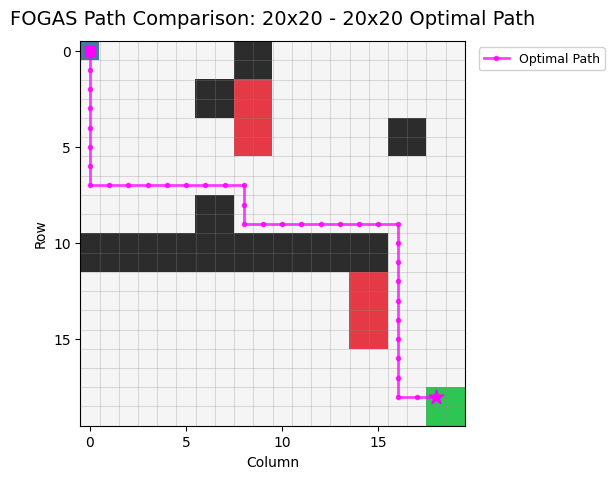

20x20:
  N=400, A=4
  feature_dim=208
Aligned with 10x10: True


In [73]:
# -----------------------------
# 20x20 macro dataset, clean FOGAS version
# Reproduces old 20grid_opt repeated-action macro collection
# -----------------------------

def scale_grid_goal_block(small_grid, factor=2):
    """
    Refine each coarse cell into a factor x factor block.
    Keep one S, but expand G to the full factor x factor block.
    """
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)

    s_pos = np.argwhere(small_grid == "S")[0]
    g_pos = np.argwhere(small_grid == "G")[0]

    large_grid[large_grid == "S"] = "."

    s_big = tuple((s_pos * factor).tolist())
    large_grid[s_big] = "S"

    g_r, g_c = (g_pos * factor).tolist()
    large_grid[g_r:g_r + factor, g_c:g_c + factor] = "G"

    return large_grid


# 1. Define base grid and scale it for aggregation
grid_10 = np.array([list(row) for row in grid_layout])
grid_20 = scale_grid_goal_block(grid_10, factor=2)
size_10, size_20 = grid_10.shape[0], grid_20.shape[0]

# 2. Generate MDP components freshly
mdp_data_10 = generate_mdp_regular_grid(grid_10)
mdp_data_20 = generate_mdp_regular_grid(grid_20)

# 3. Extract the ground-truth feature space
fixed_centers = mdp_data_10["centers"]
fixed_sigma = calculate_local_sigma(fixed_centers, k=2)

# 4. Define aligned 10x10 and 20x20 feature maps
phi_10_fixed = get_phi_func(
    fixed_centers,
    fixed_sigma,
    size_10,
    mdp_data_10["pits"],
    mdp_data_10["goal"],
    A=mdp_data_10["A"],
)

phi_20_fixed = get_phi_func(
    fixed_centers,
    fixed_sigma,
    size_20,
    mdp_data_20["pits"],
    mdp_data_20["goal"],
    A=mdp_data_20["A"],
)

# 5. Build clean MDP + planner
mdp_20, planner_20 = build_clean_mdp_from_grid_data(mdp_data_20)

# Optional: inspect optimal path
optimal_path_20 = compute_optimal_path(
    planner_20,
    mdp_data_20,
    size=size_20,
)

plot_agent_paths_with_labels(
    grid_20,
    [optimal_path_20],
    labels=["Optimal Path"],
    title_suffix="- 20x20 Optimal Path",
)

print("20x20:")
print(f"  N={mdp_20.N}, A={mdp_20.A}")
print(f"  feature_dim={phi_20_fixed(0, 0).numel()}")
print("Aligned with 10x10:", phi_20_fixed(0, 0).numel() == phi_10_fixed(0, 0).numel())

# 6. Plot occupancy, same as old notebook but using clean Planner
probs20 = planner_20.state_mu_star.detach().cpu().numpy().copy()

terminal_indices20 = list(mdp_data_20["pits"]) + [mdp_data_20["goal"]]
for idx in terminal_indices20:
    probs20[idx] = 0.0

occupancy_grid20 = probs20.reshape(size_20, size_20)
positive_probs20 = probs20[probs20 > 0]

### Collection in coarse map

In [74]:
# 7. Collect macro dataset with repeated fine actions
MACRO_DATASET_PATH_4A = DATASET_PATH1

reset_options20 = {
    "x0": 0.0,
    "occupancy": 1.0,
}

collector20_macro = DiscreteDataBuffer(
    mdp=mdp_20,
    restricted_states=mdp_data_20["walls"],
    reset_probs=reset_options20,
    occupancy=planner_20.state_mu_star,
    terminal_states=set(mdp_data_20["pits"]) | {mdp_data_20["goal"]},
    max_steps=100,
    seed=seed,
)

epsilon_policy20 = (planner_20.pi_star, 0.3)

df_macro_4a = collector20_macro.collect_macro_dataset_n_repeated_actions(
    policy=epsilon_policy20,
    n_macro_steps=8000,
    gamma=mdp_data_20["gamma"],
    fine_size=20,
    coarse_size=10,
    factor=2,
    n_repeats=2,
    save_path=str(MACRO_DATASET_PATH_4A),
    verbose=True,
)

Collected 8000 macro transitions (2 fine steps each).
Saved FOGAS macro dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets/large_20grid/20grid_coarse.csv


### Coarse MDP construction

In [75]:
# 8. Build the clean 4-action coarse MDP and pass it to FOGAS

size_macro = size_10
mdp_data_macro_base = mdp_data_10
terminal_states_macro_4a = list(mdp_data_macro_base["pits"]) + [mdp_data_macro_base["goal"]]

def fine_to_coarse_state(x_fine, fine_size=20, coarse_size=10, factor=2):
    r_f, c_f = divmod(int(x_fine), int(fine_size))
    r_c, c_c = r_f // int(factor), c_f // int(factor)
    return int(r_c * int(coarse_size) + c_c)

def coarse_to_fine_block_states(x_coarse, coarse_size=10, factor=2, fine_size=20):
    r_c, c_c = divmod(int(x_coarse), int(coarse_size))
    return [
        int((r_c * factor + dr) * fine_size + (c_c * factor + dc))
        for dr in range(int(factor))
        for dc in range(int(factor))
    ]

def build_repeated_action_macro_model(
    mdp_fine,
    terminal_states_coarse,
    *,
    fine_size=20,
    coarse_size=10,
    factor=2,
    n_repeats=2,
):
    """
    Build the coarse model matching collect_macro_dataset_n_repeated_actions:
    one macro action is one fine action repeated n_repeats times.
    """
    num_coarse_states = int(coarse_size) * int(coarse_size)
    num_actions = int(mdp_fine.A)
    gamma_fine = float(mdp_fine.gamma)

    P_fine = mdp_fine.P.detach().cpu().to(dtype=torch.float64).reshape(
        mdp_fine.N, mdp_fine.A, mdp_fine.N
    )
    r_fine = mdp_fine.r.detach().cpu().to(dtype=torch.float64).reshape(
        mdp_fine.N, mdp_fine.A
    )

    P_macro = torch.zeros(
        (num_coarse_states * num_actions, num_coarse_states),
        dtype=torch.float64,
    )
    r_macro = torch.zeros(num_coarse_states * num_actions, dtype=torch.float64)

    terminal_states_coarse = set(int(s) for s in terminal_states_coarse)

    for x_c in range(num_coarse_states):
        fine_block = coarse_to_fine_block_states(
            x_c,
            coarse_size=coarse_size,
            factor=factor,
            fine_size=fine_size,
        )

        for a in range(num_actions):
            row_idx = x_c * num_actions + a

            if x_c in terminal_states_coarse:
                P_macro[row_idx, x_c] = 1.0
                terminal_reward = 10.0 if x_c == mdp_data_macro_base["goal"] else -10.0
                r_macro[row_idx] = sum(
                    (gamma_fine ** k) * terminal_reward
                    for k in range(n_repeats)
                )
                continue

            coarse_next_probs = torch.zeros(num_coarse_states, dtype=torch.float64)
            expected_macro_reward = 0.0

            for x_f in fine_block:
                state_probs = torch.zeros(mdp_fine.N, dtype=torch.float64)
                state_probs[int(x_f)] = 1.0

                for k in range(int(n_repeats)):
                    expected_macro_reward += (gamma_fine ** k) * float(state_probs @ r_fine[:, a])
                    state_probs = state_probs @ P_fine[:, a, :]

                for x_f_next, prob_next in enumerate(state_probs):
                    prob_next = float(prob_next.item())
                    if prob_next == 0.0:
                        continue

                    x_c_next = fine_to_coarse_state(
                        x_f_next,
                        fine_size=fine_size,
                        coarse_size=coarse_size,
                        factor=factor,
                    )
                    coarse_next_probs[x_c_next] += prob_next

            coarse_next_probs /= len(fine_block)
            expected_macro_reward /= len(fine_block)

            total = coarse_next_probs.sum().item()
            if total > 1e-12:
                coarse_next_probs /= total
            else:
                coarse_next_probs[x_c] = 1.0

            P_macro[row_idx] = coarse_next_probs
            r_macro[row_idx] = expected_macro_reward

    return P_macro, r_macro


P_macro_4a, r_macro_4a = build_repeated_action_macro_model(
    mdp_fine=mdp_20,
    terminal_states_coarse=terminal_states_macro_4a,
    fine_size=size_20,
    coarse_size=size_macro,
    factor=2,
    n_repeats=2,
)


def phi_macro_4a(x, a):
    return phi_10(x, a)

In [76]:
gamma_macro_4a = mdp_data_20["gamma"] ** 2

mdp_macro_4a = DiscreteMDP(
    states=torch.arange(size_macro * size_macro, dtype=torch.int64),
    actions=torch.arange(mdp_data_20["A"], dtype=torch.int64),
    r=r_macro_4a,
    gamma=gamma_macro_4a,
    x0=mdp_data_macro_base["start"],
    P=P_macro_4a,
    terminal_states=terminal_states_macro_4a,
)

planner_macro_4a = Planner(mdp_macro_4a)

solver_macro_4a = FOGASSolver(
    mdp=mdp_macro_4a,
    phi=phi_macro_4a,
    csv_path=str(MACRO_DATASET_PATH_4A),
    device=device,
    beta=1e-7,
    seed=seed,
)

evaluator_macro_4a = FOGASEvaluator(
    solver=solver_macro_4a,
    planner=planner_macro_4a,
)

[FOGASSolver] omega estimated via regression (beta_omega=1.00e-07, n=8000)


### Solving in coarse MDP and passing to fine

In [77]:
solver_macro_4a.run(
    alpha=0.001,
    eta=0.0002,
    rho=0.5,
    tqdm_print=True,
    T=15000,
)

FOGAS:   0%|                                                                                                                                                                                                                  | 0/15000 [00:00<?, ?it/s]

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [00:10<00:00, 1460.22it/s]


tensor([[7.9278e-02, 7.0156e-01, 1.2136e-01, 9.7804e-02],
        [5.2311e-05, 6.8752e-01, 3.1243e-01, 1.4535e-07],
        [3.6593e-06, 3.4213e-04, 9.9965e-01, 3.2618e-15],
        [1.3523e-04, 7.8682e-08, 9.9986e-01, 3.2850e-19],
        [3.3974e-02, 2.3211e-08, 9.6603e-01, 2.2776e-17],
        [9.5313e-02, 7.6110e-07, 9.0469e-01, 5.1596e-13],
        [1.9033e-03, 9.3793e-06, 9.9809e-01, 2.9245e-09],
        [1.6196e-05, 1.1807e-05, 9.9997e-01, 8.7263e-07],
        [6.0495e-06, 1.4210e-05, 9.9996e-01, 2.4348e-05],
        [2.3729e-04, 1.1752e-05, 9.9969e-01, 5.9320e-05],
        [1.2864e-11, 9.9998e-01, 1.7791e-05, 6.2581e-07],
        [2.3779e-14, 9.9994e-01, 5.7339e-05, 8.8367e-12],
        [7.1401e-10, 4.4316e-01, 5.5684e-01, 1.7630e-14],
        [1.9995e-05, 5.3520e-04, 9.9944e-01, 1.8057e-16],
        [4.8060e-02, 8.1155e-05, 9.5186e-01, 2.1517e-06],
        [9.0802e-01, 4.0555e-02, 5.1421e-02, 1.7559e-10],
        [1.4878e-01, 4.1254e-01, 4.3868e-01, 1.9980e-07],
        [9.348

In [78]:
NUM_EVAL_TRAJ = 100
MAX_EVAL_STEPS = 100

avg_reward_macro_4a = evaluator_macro_4a.average_return(
    policy_mode="solver",
    num_trajectories=NUM_EVAL_TRAJ,
    max_steps=MAX_EVAL_STEPS,
    seed=seed,
    goal_state=mdp_data_macro_base["goal"],
    terminal_states=terminal_states_macro_4a,
)["policy"]

greedy_reward_macro_4a = evaluator_macro_4a.average_return(
    policy_mode="greedy",
    num_trajectories=NUM_EVAL_TRAJ,
    max_steps=MAX_EVAL_STEPS,
    seed=seed,
    goal_state=mdp_data_macro_base["goal"],
    terminal_states=terminal_states_macro_4a,
)["policy"]

success_rate_macro_4a = evaluator_macro_4a.success_rate(
    policy_mode="solver",
    goal_state=mdp_data_macro_base["goal"],
    num_trajectories=NUM_EVAL_TRAJ,
    max_steps=MAX_EVAL_STEPS,
    seed=seed,
    terminal_states=terminal_states_macro_4a,
)["policy"]

print(f"Avg reward:     {avg_reward_macro_4a:.6f}")
print(f"Greedy reward:  {greedy_reward_macro_4a:.6f}")
print(f"Success rate:   {success_rate_macro_4a:.3f}")

Avg reward:     0.516231
Greedy reward:  1.456791
Success rate:   0.860


# Final Policies:

In [79]:
def rollout_macro_policy_on_fine_mdp(
    pi_macro,
    mdp_fine,
    mdp_data_fine,
    *,
    fine_size=20,
    coarse_size=10,
    factor=2,
    n_repeats=2,
    max_macro_steps=100,
):
    pi_macro = pi_macro.detach().cpu()

    x = int(mdp_data_fine["start"])
    goal = int(mdp_data_fine["goal"])
    pits = set(int(p) for p in mdp_data_fine["pits"])

    fine_path = [x]
    macro_actions = []

    for _ in range(max_macro_steps):
        # fine state -> coarse state
        r_f, c_f = divmod(x, fine_size)
        r_c, c_c = r_f // factor, c_f // factor
        x_coarse = r_c * coarse_size + c_c

        # choose coarse action; this is also the fine action to repeat
        a = int(torch.argmax(pi_macro[x_coarse]).item())
        macro_actions.append(a)

        # apply same fine action twice
        for _ in range(n_repeats):
            row = x * mdp_fine.A + a
            x_next = int(torch.argmax(mdp_fine.P[row]).item())  # deterministic grid

            fine_path.append(x_next)
            x = x_next

            if x == goal or x in pits:
                return fine_path, macro_actions

    return fine_path, macro_actions

20x20 equivalent policy shapes:
  strategy_1: pi_20 shape=(400, 4), greedy rollout len=36, reached_goal=True
  coarse: pi_20 shape=(400, 4), greedy rollout len=36, reached_goal=True

Fine 20x20 evaluation with repeated macro actions:


,policy,mode,avg_reward,reward_std,success_rate
0,strategy_1,solver,-0.543723,0.263950,0.548
1,strategy_1,greedy,-0.303587,NaN,1.000
2,coarse,solver,-0.494455,0.252487,0.599
3,coarse,greedy,-0.303587,NaN,1.000


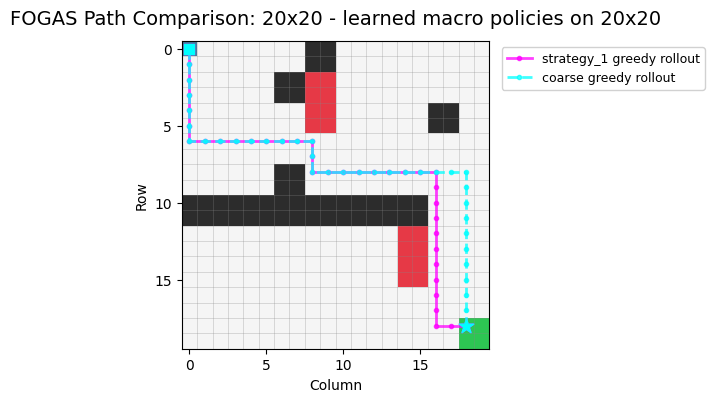

In [84]:
# ------------------------------------------------------------
# Compare both learned 10x10 macro policies on the fine 20x20 MDP
#   - strategy_1: policy learned directly on the 10x10/strategy-1 dataset
#   - coarse:     policy learned on the repeated-action coarse macro model
# ------------------------------------------------------------

NUM_EVAL_TRAJ = 1000
MAX_MACRO_STEPS = 100


def macro_policy_to_fine_policy(
    pi_macro,
    *,
    fine_size=20,
    coarse_size=10,
    factor=2,
):
    """Expand a 10x10 macro policy to a 20x20 block policy."""
    pi_macro = pi_macro.detach().cpu().to(dtype=torch.float64)
    pi_fine = torch.zeros((fine_size * fine_size, pi_macro.shape[1]), dtype=torch.float64)

    for x_fine in range(fine_size * fine_size):
        r_f, c_f = divmod(x_fine, fine_size)
        r_c, c_c = r_f // factor, c_f // factor
        x_coarse = r_c * coarse_size + c_c
        pi_fine[x_fine] = pi_macro[x_coarse]

    pi_fine = torch.clamp(pi_fine, min=0.0)
    row_sums = pi_fine.sum(dim=1, keepdim=True)
    bad_rows = row_sums.squeeze() <= 0
    pi_fine = pi_fine / torch.clamp(row_sums, min=1e-12)
    if bad_rows.any():
        pi_fine[bad_rows] = 1.0 / pi_fine.shape[1]

    return pi_fine


def eval_macro_policy_on_fine_mdp_with_stats(
    pi_macro,
    *,
    policy_mode="solver",
    num_trajectories=1000,
    max_macro_steps=100,
    seed=seed,
    fine_size=20,
    coarse_size=10,
    factor=2,
    n_repeats=2,
):
    pi_macro = pi_macro.detach().cpu().to(dtype=torch.float64)

    goal = int(mdp_data_20["goal"])
    pits = set(int(p) for p in mdp_data_20["pits"])
    terminal_states_fine = pits | {goal}

    returns = []
    successes = 0

    for traj_idx in range(num_trajectories):
        torch.manual_seed(seed + traj_idx)

        x = int(mdp_data_20["start"])
        total_return = 0.0
        fine_step = 0

        for _ in range(max_macro_steps):
            r_f, c_f = divmod(x, fine_size)
            r_c, c_c = r_f // factor, c_f // factor
            x_coarse = r_c * coarse_size + c_c

            if policy_mode == "greedy":
                a = int(torch.argmax(pi_macro[x_coarse]).item())
            elif policy_mode == "solver":
                probs = torch.clamp(pi_macro[x_coarse], min=0.0)
                probs = probs / probs.sum() if probs.sum() > 0 else torch.ones_like(probs) / len(probs)
                a = int(torch.multinomial(probs, num_samples=1).item())
            else:
                raise ValueError("policy_mode must be 'solver' or 'greedy'")

            for _ in range(n_repeats):
                row = x * mdp_20.A + a

                reward = float(mdp_20.r[row].item())
                total_return += (mdp_20.gamma ** fine_step) * reward

                next_probs = mdp_20.P[row].detach().cpu().to(dtype=torch.float64)
                x = int(torch.multinomial(next_probs, num_samples=1).item())
                fine_step += 1

                if x in terminal_states_fine:
                    successes += int(x == goal)
                    returns.append(total_return)
                    break

            if x in terminal_states_fine:
                break
        else:
            returns.append(total_return)

    returns = np.asarray(returns, dtype=float)
    return {
        "avg_reward": float(returns.mean()) if len(returns) else np.nan,
        "reward_std": float(returns.std(ddof=1)) if len(returns) > 1 else 0.0,
        "success_rate": float(successes / num_trajectories) if num_trajectories else np.nan,
        "num_trajectories": int(num_trajectories),
    }


macro_policies = {
    "strategy_1": solver_10.pi,
    "coarse": solver_macro_4a.pi,
}

# 20x20 block-policy equivalents. These are useful for plotting/inspection;
# evaluation below still repeats the chosen macro action twice, matching the dataset.
pi_20_equivalent = {
    name: macro_policy_to_fine_policy(
        pi,
        fine_size=size_20,
        coarse_size=size_macro,
        factor=2,
    )
    for name, pi in macro_policies.items()
}

# Use the rollout helper to get the deterministic greedy fine paths for both.
rollout_results = {}
for name, pi in macro_policies.items():
    fine_path, macro_actions = rollout_macro_policy_on_fine_mdp(
        pi,
        mdp_20,
        mdp_data_20,
        fine_size=size_20,
        coarse_size=size_macro,
        factor=2,
        n_repeats=2,
        max_macro_steps=MAX_MACRO_STEPS,
    )
    rollout_results[name] = {
        "fine_path": fine_path,
        "fine_path_coords": [divmod(int(s), size_20) for s in fine_path],
        "macro_actions": macro_actions,
    }

comparison_rows = []
for name, pi in macro_policies.items():
    for mode in ["solver", "greedy"]:
        stats = eval_macro_policy_on_fine_mdp_with_stats(
            pi,
            policy_mode=mode,
            num_trajectories=NUM_EVAL_TRAJ,
            max_macro_steps=MAX_MACRO_STEPS,
            seed=seed,
            fine_size=size_20,
            coarse_size=size_macro,
            factor=2,
            n_repeats=2,
        )
        comparison_rows.append({
            "policy": name,
            "mode": mode,
            "avg_reward": stats["avg_reward"],
            "reward_std": stats["reward_std"] if mode == "solver" else np.nan,
            "success_rate": stats["success_rate"],
        })

comparison_df = pd.DataFrame(comparison_rows)

print("20x20 equivalent policy shapes:")
for name, pi_fine in pi_20_equivalent.items():
    path = rollout_results[name]["fine_path"]
    reached_goal = int(path[-1]) == int(mdp_data_20["goal"])
    print(f"  {name}: pi_20 shape={tuple(pi_fine.shape)}, greedy rollout len={len(path) - 1}, reached_goal={reached_goal}")

print("\nFine 20x20 evaluation with repeated macro actions:")
display(comparison_df)

plot_agent_paths_with_labels(
    grid_20,
    [rollout_results["strategy_1"]["fine_path_coords"], rollout_results["coarse"]["fine_path_coords"]],
    labels=["strategy_1 greedy rollout", "coarse greedy rollout"],
    title_suffix="- learned macro policies on 20x20",
)
